# Mathematical Engineering - Financial Engineering, FY 2025-2026
# Risk Management - Exercise 5: Extended Vasiceck model Monte Carlo simulation for CCR estimation

#### Import the libraries and functions needed created in previous labs

In [1]:
# Importing the libraries
import os
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from utilities.date_functions import (
    business_date_offset,
    date_series,
    year_frac_act_x,
    year_frac_30e_360
)

from utilities.ex0_utilities import (
    bootstrap,
    from_discount_factors_to_zero_rates,
    get_discount_factor_by_zero_rates_linear_interp)

from utilities.ex1_utilities import (
    swap_par_rate,
    SwapType
)

from utilities.ex5_utilities import (
    simulate_ou_process,
    affine_trick,
    update_collateral
)

#### Bootstrap 

In [2]:
data_path = Path("data")
today = pd.Timestamp(2008, 2, 19)

# Dates
dates_df = pd.read_csv(
    data_path / "dt.csv",
    index_col='Market',
    usecols=['Market', 'TARGET'],
    converters={'TARGET': pd.to_datetime}
)

settlement_date = dates_df.loc['Settlement', 'TARGET']

# Depos
depo_converter = lambda x: float(x) / 100.0

df_depos = pd.read_csv(
    data_path / "depos.csv",
    index_col='Depos',
    usecols=['Depos', 'ASK', 'BID'],
    converters={
        'Depos': pd.to_datetime,
        'BID': depo_converter,
        'ASK': depo_converter
    }
)

# Futures
future_converter = lambda x: float(x)

futures = pd.read_csv(
    data_path / "futures.csv",
    index_col='Futures',
    usecols=['Futures', 'ASK', 'BID'],
    converters={
        'Futures': pd.to_datetime,
        'BID': future_converter,
        'ASK': future_converter
    }
)

expiry = pd.read_csv(
    data_path / "expiry.csv",
    index_col='Futures',
    usecols=['Futures', 'Settle', 'Expiry'],
    converters={
        'Futures': pd.to_datetime,
        'Settle': pd.to_datetime,
        'Expiry': pd.to_datetime
    }
)

df_futures = futures.join(expiry)

# Swaps
swap_converter = lambda x: float(x)

df_swaps = pd.read_csv(
    data_path / "swaps.csv",
    index_col='Swaps',
    usecols=['Swaps', 'BID', 'ASK'],
    converters={
        'Swaps': pd.to_datetime,
        'BID': swap_converter,
        'ASK': swap_converter
    }
)

# Bootstrap
discount_factors, zero_rates = bootstrap(
    settlement_date,
    df_depos,
    df_futures,
    df_swaps
)

display(discount_factors)

2008-02-19    1.000000
2008-02-20    0.999889
2008-02-26    0.999209
2008-03-19    0.996664
2008-06-19    0.985787
2008-09-18    0.976098
2008-12-17    0.967330
2009-03-17    0.959005
2009-06-18    0.950661
2009-09-17    0.942498
2009-12-16    0.934302
2010-02-19    0.926897
2011-02-21    0.891615
2012-02-20    0.855991
2013-02-19    0.819887
2014-02-19    0.783754
2015-02-19    0.747803
2016-02-19    0.712371
2017-02-20    0.677734
2018-02-19    0.644301
2019-02-19    0.612067
2020-02-19    0.581076
2021-02-19    0.551908
2022-02-21    0.523910
2023-02-20    0.497609
2024-02-19    0.472737
2025-02-19    0.449183
2026-02-19    0.426982
2027-02-19    0.406056
2028-02-21    0.386237
2029-02-19    0.367744
2030-02-19    0.350232
2031-02-19    0.333729
2032-02-19    0.318187
2033-02-21    0.303477
2034-02-20    0.289728
2035-02-19    0.276763
2036-02-19    0.264486
2037-02-19    0.252890
2038-02-19    0.241918
2039-02-21    0.231456
2040-02-20    0.221611
2041-02-19    0.212275
2042-02-19 

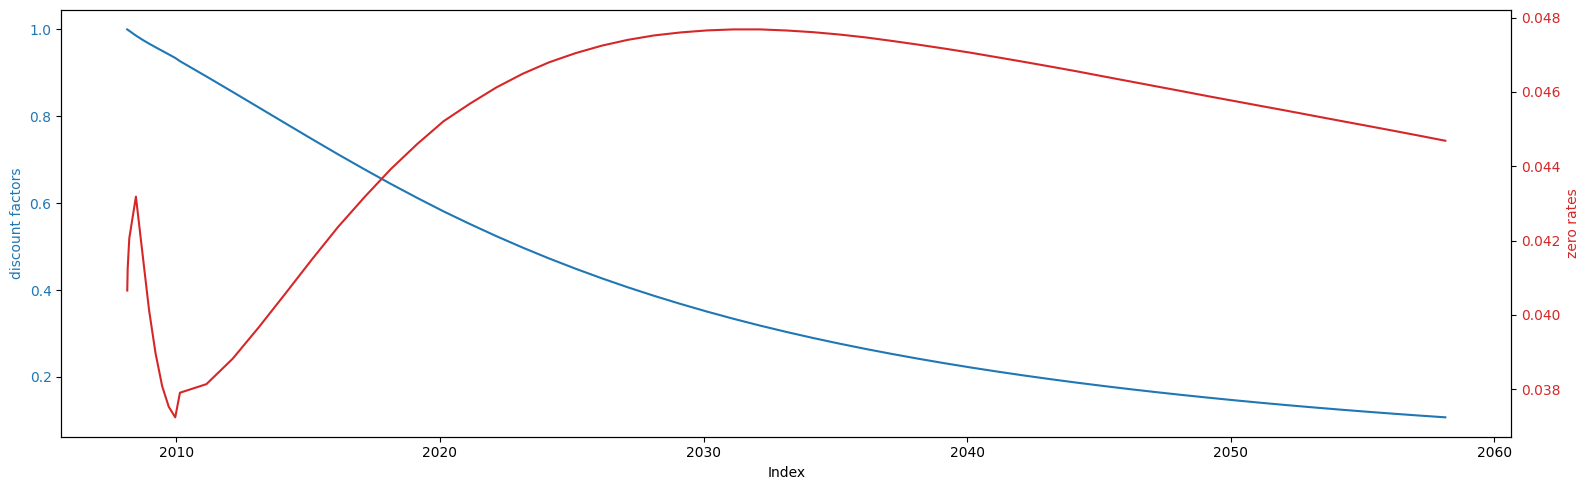

In [3]:
fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(discount_factors.index, discount_factors.values, color='tab:blue')
ax1.set_ylabel('discount factors', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(zero_rates.index, zero_rates.values, color='tab:red')
ax2.set_ylabel('zero rates', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_xlabel('Index')
plt.tight_layout()

plt.show()


#### MonteCarlo grid set up

In [ ]:
# Monte Carlo Simulations parameters, grids and outputs to store
np.random.seed(42)   #we need to set the seed 
# params
simulations_num = 250_000   # MISTAKE: it was 100_000
years_to_simulate = 10

# last point on the simulation grid
simulations_expiry = business_date_offset(settlement_date, month_offset=years_to_simulate * 12)    #MISTAKE: this was 10 months instead of years

# 40 simulation dates (t_0 non a simulation date)
total_point = 40
point_per_year = total_point//years_to_simulate
simulation_grid = date_series(settlement_date, simulations_expiry, point_per_year)[1:]


# output to compute
expected_positive_exposure = pd.DataFrame(
    data=0.0, index=simulation_grid,
    columns=["base", "break", "swap2", "no netting", "netting", "collateral"])

alpha = 0.95
potential_future_exposure = pd.DataFrame(
    data=0.0, index=simulation_grid,
    columns=["base", "break", "swap2", "no netting", "netting", "collateral"])

#### Set up of the base contract

In [5]:
####### 10 y payer swap #######

# Parameters for the 10y payer swap
notional = 100_000_000
swap_type = SwapType.PAYER
maturity = 10
fixed_freq = 1 # annual

# expiry date
expiry = business_date_offset(settlement_date, month_offset=maturity * 12)
fixed_leg_payment_dates = date_series(settlement_date, expiry, fixed_freq)

# assume swap traded at par
swap_rate = swap_par_rate(fixed_leg_payment_dates, discount_factors)

# fixed leg cash flows
irs_cash_flows = pd.Series(
    data=[
        swap_rate * year_frac_30e_360(fixed_leg_payment_dates[count-1], fixed_leg_payment_dates[count])      # MISTAKE: yearfract missing
        for count in range(1, len(fixed_leg_payment_dates))],
    index=fixed_leg_payment_dates[1:])   
irs_cash_flows.iloc[-1] += 1.0  # rimborso nozionale 

assert set(fixed_leg_payment_dates[1:]).issubset(set(simulation_grid)), \
    "Alcune date di pagamento fisso non sono presenti nella simulation_grid"

# fixed leg cash flows extended on simulation grid
# verify that all the payments fall on a t already included in the simulation grid
irs_cash_flows_extended = (
    irs_cash_flows
    .reindex(simulation_grid, fill_value=0.0)
)


#### Set up of the alternative scenarios 

In [6]:
# a) mandatory break clause
# Set up of the break date
break_year = 3
break_month = 6

#brake date
break_expiry = business_date_offset(settlement_date, month_offset=break_year * 12 + break_month)

assert break_expiry in simulation_grid, \
    f"break_expiry={break_expiry.date()} non è in simulation_grid; controllare date_series/business_date_offset"

# b) 5y receiver swap
# Parameters for the 5y receiver swap
# swap 2 has fixed leg quarterly, float leg quarterly (euribor 3m), same yf conventions of base swap
notional_2 = 150_000_000
swap_type_2 = SwapType.RECEIVER
maturity_2 = 5
fixed_freq_2 = 4 

expiry_2 = business_date_offset(settlement_date, month_offset=maturity_2 * 12)
fixed_leg_payment_dates_2 = date_series(settlement_date, expiry_2, fixed_freq_2)

# assume swap traded at par
swap_rate_2 = swap_par_rate(fixed_leg_payment_dates_2, discount_factors)

# fixed leg cash flows
irs_cash_flows_2 = pd.Series(
    data=[
        swap_rate_2 * year_frac_30e_360(fixed_leg_payment_dates_2[count-1], fixed_leg_payment_dates_2[count])      # MISTAKE: yearfract missing
        for count in range(1, len(fixed_leg_payment_dates_2))],
    index=fixed_leg_payment_dates_2[1:])   
    

# fixed leg cash flows extended on simulation grid
irs_cash_flows_extended_2 = (
    irs_cash_flows_2
    .reindex(simulation_grid, fill_value=0.0)
)



# c) CSA agreement
# No IA, no rounding, no haircut, no delay in the posting of the collateral (i.e. margin call done at t -> new collateral posted at t)
# CSA parameters for party B (Polimi Bank)

THR_B = np.inf
MTA_B = 0      # given, choose correctly the other parameters
Cap_B = np.inf # given, choose correctly the other parameters

THR_C = 0 
MTA_C = 0      # given, choose correctly the other parameters
Cap_C = np.inf

#### x_t OU Process simulations

In [7]:
# OU process parameters

mean_reversion = 0.0205
sigma = 0.0094

In [8]:
x_paths = simulate_ou_process(simulation_grid,
                              settlement_date, 
                              mean_reversion, 
                              sigma, 
                              simulations_num,
                              x0=0)

#### From OU to discount factors and MtM and exposures

In [9]:
# Inizialization of zero rates
zero_rates = (
    zero_rates.reindex(zero_rates.index.union([simulation_grid[0]]))
    .sort_index()
    .interpolate(method="index")
)

# Inizialization collateral
collateral_posted = np.zeros(simulations_num)
risk_free_rate = np.full(simulations_num, zero_rates.loc[simulation_grid[0]])
last_collateral_posting_date = settlement_date


for i, sim_date in enumerate(simulation_grid[0:]):

    prev_date = settlement_date if i == 0 else simulation_grid[i - 1]
    dt = year_frac_act_x(prev_date, sim_date, 360)

    # Market simulation at time sim_date
    x_t = x_paths[:, i]

    # A and C changes at each sim_date, but are common across simulations
    A, C = affine_trick(sim_date, simulation_grid, mean_reversion, sigma, discount_factors)

    # discounts factor (sim_date,t_j) in each scenario, for each t_j in the simulation_grid, use the affine formula 
    discount_factors_hw = A.values[np.newaxis, :] * np.exp(-np.outer(x_t, C.values)) 
    
    # discounted cashflows 
    discounted_cash_flows = discount_factors_hw[:, i+1:] @ irs_cash_flows_extended.values[i+1:]

    # mark-to-future (MtM_t)
    MtF = notional * (1- discounted_cash_flows)  
    

    # remunerate the collateral posted
    collateral_posted *= np.exp(risk_free_rate * dt)

    if (sim_date - last_collateral_posting_date).days >= 360:
        last_collateral_posting_date = sim_date
        collateral_posted = update_collateral(MtF,collateral_posted,THR_B,THR_C,MTA_B,MTA_C,Cap_B,Cap_C)
    
    MtF_coll = MtF - collateral_posted

    # Positive exposure
    MtF_pos      = np.maximum(MtF, 0)
    MtF_pos_coll = np.maximum(MtF_coll, 0)
        
    # Break 
    if sim_date <= break_expiry:
        MtF_pos_break = MtF_pos
    else:
        MtF_pos_break = np.zeros(simulations_num)
 
    if sim_date < expiry_2:
        idx_mat_2 = simulation_grid.index(expiry_2)
        
        fixed_pv_2 = discount_factors_hw[:, i+1:] @ irs_cash_flows_extended_2.values[i+1:]
        float_pv_2 = 1.0 - discount_factors_hw[:, idx_mat_2]
        MtF_2 = notional_2 * (fixed_pv_2 - float_pv_2)
    else:
        MtF_2 = np.zeros(simulations_num)

    # Positive exposure swap 2 standalone        
    MtF_pos_swap2 = np.maximum(MtF_2, 0.0)

    # No Netting: 
    MtF_pos_no_netting = MtF_pos + np.maximum(MtF_2, 0.0)
    
    # Netting:
    MtF_pos_netting = np.maximum(MtF + MtF_2, 0.0)

    # Risk-free rate update
    if i < len(simulation_grid) - 1:

        idx = A.index.get_loc(sim_date)

        risk_free_rate = -np.log(discount_factors_hw[:, idx + 1]) / year_frac_act_x(
            sim_date,
            simulation_grid[idx + 1],
            360,
        )

    
    # Expected exposure
    expected_positive_exposure.loc[sim_date, "base"] = np.mean(MtF_pos)
    expected_positive_exposure.loc[sim_date, "break"] = np.mean(MtF_pos_break)
    expected_positive_exposure.loc[sim_date, "swap2"] = np.mean(MtF_pos_swap2)
    expected_positive_exposure.loc[sim_date, "no netting"] = np.mean(MtF_pos_no_netting)
    expected_positive_exposure.loc[sim_date, "netting"] = np.mean(MtF_pos_netting)
    expected_positive_exposure.loc[sim_date, "collateral"] = np.mean(MtF_pos_coll)
    # Potential future exposure
    potential_future_exposure.loc[sim_date, "base"] = np.quantile(MtF_pos, alpha)
    potential_future_exposure.loc[sim_date, "break"] = np.quantile(MtF_pos_break, alpha)
    potential_future_exposure.loc[sim_date, "swap2"] = np.quantile(MtF_pos_swap2, alpha)
    potential_future_exposure.loc[sim_date, "no netting"] = np.quantile(MtF_pos_no_netting, alpha)
    potential_future_exposure.loc[sim_date, "netting"] = np.quantile(MtF_pos_netting, alpha)
    potential_future_exposure.loc[sim_date, "collateral"] = np.quantile(MtF_pos_coll, alpha)
    

NameError: name 'alpha' is not defined

#### Peak PFE

In [ ]:
# Compute for each scenario the peak-PFE and the t at which it materialize
peak_pfe = pd.DataFrame(
    data=0,
    index=["base", "break", "swap2", "no netting", "netting", "collateral"],
    columns=['t', 'Peak_PFE'])

peak_pfe['Peak_PFE'] = potential_future_exposure.max()
peak_pfe['t']        = potential_future_exposure.idxmax()

#### PLOT 

<Figure size 1500x500 with 0 Axes>

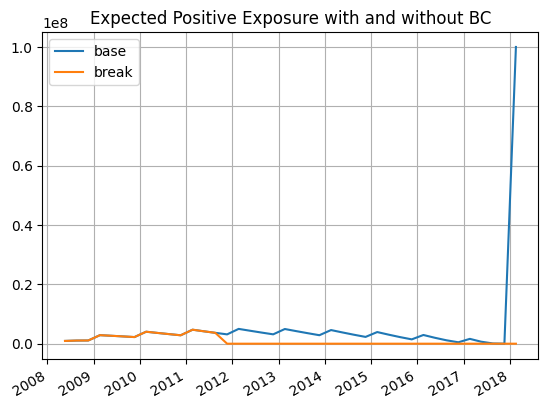

<Figure size 1500x500 with 0 Axes>

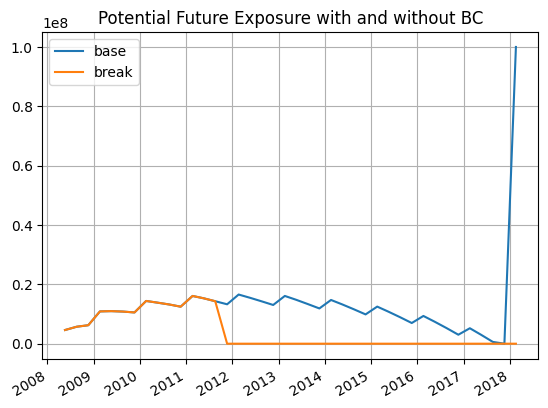

<Figure size 1500x500 with 0 Axes>

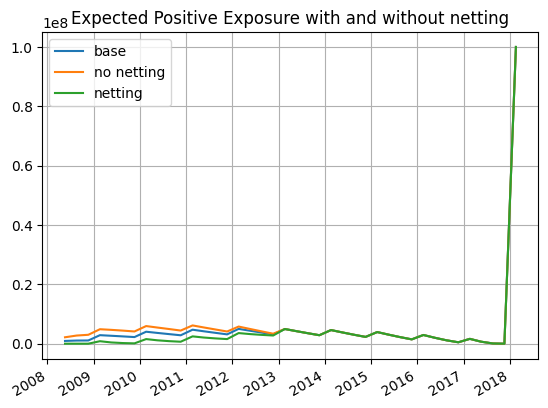

<Figure size 1500x500 with 0 Axes>

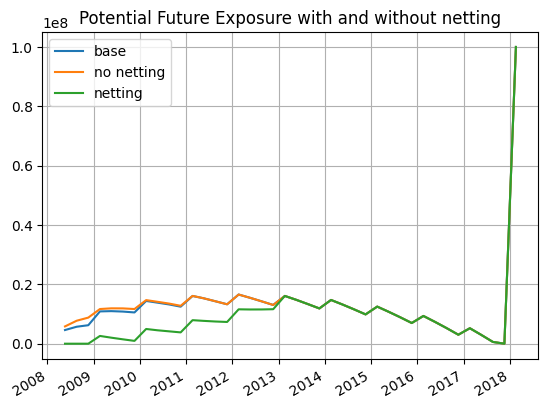

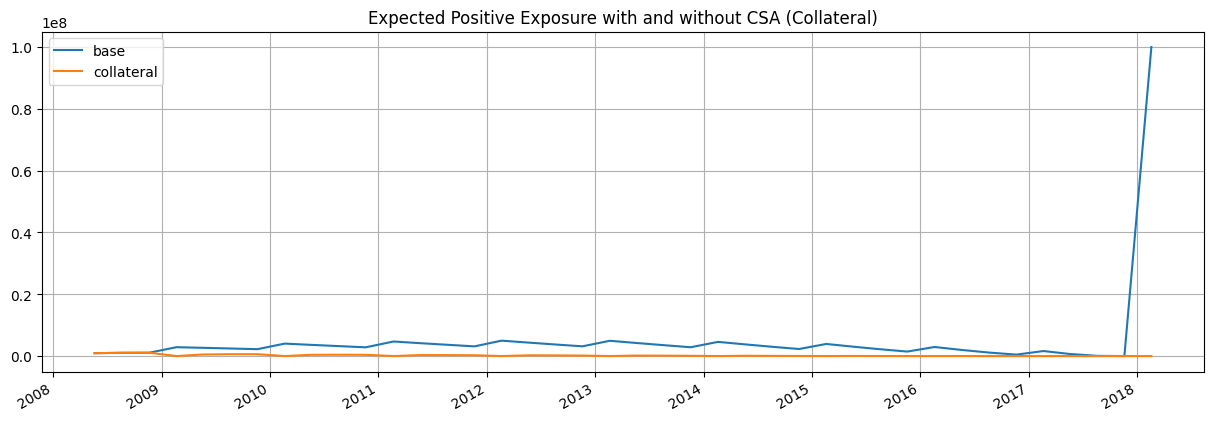

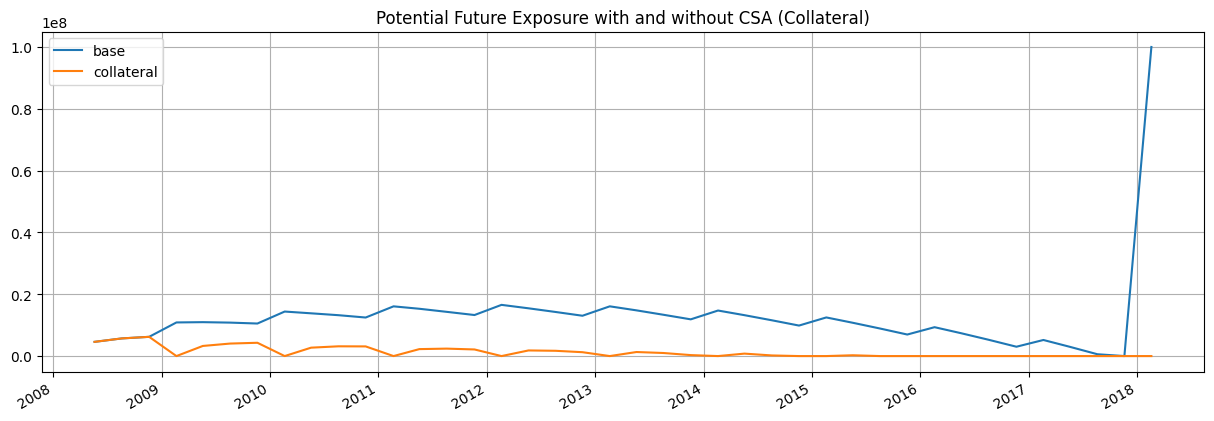

In [ ]:
### plot 6 a
plt.figure(figsize=(15, 5))
expected_positive_exposure[['base','break']].plot()
plt.title(f"Expected Positive Exposure with and without BC")
plt.grid()
plt.show()

plt.figure(figsize=(15, 5))
potential_future_exposure[['base','break']].plot()
plt.title(f"Potential Future Exposure with and without BC")
plt.grid()
plt.show()

### plot 6 b
plt.figure(figsize=(15, 5))
expected_positive_exposure[['base', 'swap2', 'no netting', 'netting']].plot()
plt.title(f"Expected Positive Exposure: base and swap2 with and without netting")
plt.grid()
plt.show()

plt.figure(figsize=(15, 5))
potential_future_exposure[['base','swap2','no netting', 'netting']].plot()
plt.title(f"Potential Future Exposure: base and swap2 with and without netting")
plt.grid()
plt.show()

### plot 6 c

plt.figure(figsize=(15, 5))
expected_positive_exposure[['base', 'collateral']].plot(ax=plt.gca())
plt.title("Expected Positive Exposure with and without CSA (Collateral)")
plt.grid()
plt.show()

plt.figure(figsize=(15, 5))
potential_future_exposure[['base', 'collateral']].plot(ax=plt.gca())
plt.title("Potential Future Exposure with and without CSA (Collateral)")
plt.grid()
plt.show()


#### CVA estimations

In [ ]:
# Parameters
hazard_rate = 0.02
lgd = 0.6

In [ ]:
# CVA computation
# Assumptions: LGD=60%, lambda=200bps flat, unilateral (only counterparty can default),
# independence between exposures and default

cva_results = {}

for scenario in expected_positive_exposure.columns:
    cva = 0.0
    for i, sim_date in enumerate(simulation_grid):
        prev_date = settlement_date if i == 0 else simulation_grid[i - 1]

        # year fractions from t0
        t_prev = year_frac_act_x(settlement_date, prev_date, 360)
        t_curr = year_frac_act_x(settlement_date, sim_date, 360)

        # Marginal default probability in (t_{i-1}, t_i]: S(t_{i-1}) - S(t_i)
        marginal_pd = np.exp(-hazard_rate * t_prev) - np.exp(-hazard_rate * t_curr)

        # Risk-free discount factor B(0, t_i) from bootstrapped curve
        df_t = get_discount_factor_by_zero_rates_linear_interp(
            settlement_date,
            sim_date,
            discount_factors.index,
            discount_factors.values
        )

        # EPE at t_i for this scenario
        epe = expected_positive_exposure.loc[sim_date, scenario]

        cva += lgd * epe * df_t * marginal_pd

    cva_results[scenario] = cva

# Display results
df_cva = pd.DataFrame.from_dict(cva_results, orient='index', columns=['CVA'])
df_cva['CVA (Millions)'] = df_cva['CVA'] / 1_000_000
display(df_cva)

,CVA,CVA (Millions)
base,411666.856264,0.411667
break,106107.276909,0.106107
no netting,483595.853319,0.483596
netting,324514.183647,0.324514
collateral,22152.084893,0.022152


In [ ]:

# Point 7.b – CVA Sensitivity Analysis (Base Case)
# Three sensitivities to the main market risk factors of the CVA:
#
#   1. CR Delta  – sensitivity to the counterparty hazard rate λ (already in notebook)
#   2. IR Delta  – sensitivity to a parallel shift of the interest-rate curve (DV01)
#   3. Vega      – sensitivity to the Hull-White volatility parameter σ

bump = 0.0001   # 1 basis point

# ── helper: recompute EPE profile given a bumped discount-factor curve
#            and/or a bumped sigma, using the same x_paths already simulated
def compute_epe_base(discount_factors_input, sigma_input):
    """
    Recompute the EPE profile for the base (10y payer) swap only,
    given a (possibly bumped) discount-factor curve and/or sigma.
    x_paths is kept fixed (same random seed) so that only the
    sensitivity to the bumped parameter is captured.
    """
    epe = np.zeros(len(simulation_grid))

    # Recompute fixed-leg cash flows on the (possibly bumped) curve
    swap_rate_bumped = swap_par_rate(fixed_leg_payment_dates, discount_factors_input)
    cf_bumped = pd.Series(
        data=[
            swap_rate_bumped * year_frac_30e_360(
                fixed_leg_payment_dates[k - 1], fixed_leg_payment_dates[k]
            )
            for k in range(1, len(fixed_leg_payment_dates))
        ],
        index=fixed_leg_payment_dates[1:],
    )
    cf_bumped.iloc[-1] += 1.0  # notional repayment at maturity
    cf_bumped_ext = cf_bumped.reindex(simulation_grid, fill_value=0.0)

    for i, sim_date in enumerate(simulation_grid):
        x_t = x_paths[:, i]

        # Affine components with (possibly bumped) curve and/or sigma
        A, C = affine_trick(
            sim_date, simulation_grid, mean_reversion, sigma_input, discount_factors_input
        )

        df_hw = A.values[np.newaxis, :] * np.exp(-np.outer(x_t, C.values))

        # MtM of the 10y payer swap (floating leg = par)
        dcf = df_hw[:, i:] @ cf_bumped_ext.values[i:]
        mtf = notional * (1.0 - dcf)

        epe[i] = np.mean(np.maximum(mtf, 0.0))

    return epe


# ── helper: compute CVA given an EPE array and a hazard rate
def compute_cva(epe_array, lambda_input, discount_factors_input):
    """
    Discrete CVA integral:
      CVA = Σ_i  LGD · EPE_i · B(0,t_i) · ΔPD_i
    """
    cva = 0.0
    for i, sim_date in enumerate(simulation_grid):
        prev_date = settlement_date if i == 0 else simulation_grid[i - 1]

        t_prev = year_frac_act_x(settlement_date, prev_date, 360)
        t_curr = year_frac_act_x(settlement_date, sim_date, 360)

        marginal_pd = np.exp(-lambda_input * t_prev) - np.exp(-lambda_input * t_curr)

        df_t = get_discount_factor_by_zero_rates_linear_interp(
            settlement_date,
            sim_date,
            discount_factors_input.index,
            discount_factors_input.values,
        )

        cva += lgd * epe_array[i] * df_t * marginal_pd

    return cva


# Base CVA (recomputed consistently via the helper, should match cva_results['base'])
epe_base_array = expected_positive_exposure["base"].values
cva_base = compute_cva(epe_base_array, hazard_rate, discount_factors)
print(f"Base CVA: {cva_base:,.2f}")

# Sensitivity 1 – CR Delta
cva_lambda_up = compute_cva(epe_base_array, hazard_rate + bump, discount_factors)
cr_delta = cva_lambda_up - cva_base

print(f"\n--- Sensitivity 1: CR Delta (∂CVA/∂λ) ---")
print(f"  Bumped CVA (λ + 1bp): {cva_lambda_up:,.2f}")
print(f"  CR Delta (+1bp in λ): {cr_delta:,.2f}")


# Sensitivity 2 – IR Delta (DV01)
# then convert back to discount factors.
zero_rates_bumped_values = zero_rates.values + bump          # parallel +1bp shift
tenors = np.array([
    year_frac_act_x(settlement_date, d, 360) for d in zero_rates.index
])
discount_factors_bumped = pd.Series(
    data=np.exp(-zero_rates_bumped_values * tenors),
    index=discount_factors.index,
)

# Recompute EPE with the bumped curve (and the same x_paths / σ)
epe_ir_up = compute_epe_base(discount_factors_bumped, sigma)

cva_ir_up  = compute_cva(epe_ir_up, hazard_rate, discount_factors_bumped)
ir_delta   = cva_ir_up - cva_base

print(f"\n--- Sensitivity 2: IR Delta / DV01 (∂CVA/∂r) ---")
print(f"  Bumped CVA (curve + 1bp): {cva_ir_up:,.2f}")
print(f"  IR Delta (+1bp parallel shift): {ir_delta:,.2f}")


# Sensitivity 3 – Vega


sigma_up = sigma + bump

# Regenerate x_paths with bumped sigma (same seed → same Brownian increments)
np.random.seed(42)
x_paths_sigma_up = simulate_ou_process(
    simulation_grid, settlement_date, mean_reversion, sigma_up, simulations_num, x0=0
)

# Temporarily swap x_paths so compute_epe_base uses the bumped paths
x_paths_original = x_paths
x_paths = x_paths_sigma_up

epe_vega_up = compute_epe_base(discount_factors, sigma_up)
cva_vega_up = compute_cva(epe_vega_up, hazard_rate, discount_factors)
vega        = cva_vega_up - cva_base

# Restore original x_paths
x_paths = x_paths_original

print(f"\n--- Sensitivity 3: Vega (∂CVA/∂σ) ---")
print(f"  Bumped CVA (σ + 1bp): {cva_vega_up:,.2f}")
print(f"  Vega (+1bp in σ): {vega:,.2f}")

# Summary table

sensitivity_summary = pd.DataFrame({
    "Sensitivity": ["CR Delta", "IR Delta (DV01)", "Vega"],
    "Risk Factor":  ["Hazard rate λ", "IR curve (parallel)", "HW volatility σ"],
    "Bump":         ["+1bp in λ", "+1bp parallel shift", "+1bp in σ"],
    "CVA Base":     [cva_base, cva_base, cva_base],
    "CVA Bumped":   [cva_lambda_up, cva_ir_up, cva_vega_up],
    "Sensitivity":  [cr_delta, ir_delta, vega],
})
display(sensitivity_summary)

Base CVA: 411,666.86

--- Sensitivity 1: CR Delta (∂CVA/∂λ) ---
  Bumped CVA (λ + 1bp): 413,458.06
  CR Delta (+1bp in λ): 1,791.20

--- Sensitivity 2: IR Delta / DV01 (∂CVA/∂r) ---
  Bumped CVA (curve + 1bp): 205,024.21
  IR Delta (+1bp parallel shift): -206,642.65

--- Sensitivity 3: Vega (∂CVA/∂σ) ---
  Bumped CVA (σ + 1bp): 210,330.83
  Vega (+1bp in σ): -201,336.03


,Sensitivity,Risk Factor,Bump,CVA Base,CVA Bumped
0,1791.201352,Hazard rate λ,+1bp in λ,411666.856264,413458.057616
1,-206642.645679,IR curve (parallel),+1bp parallel shift,411666.856264,205024.210585
2,-201336.027861,HW volatility σ,+1bp in σ,411666.856264,210330.828402
